In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

In [3]:
file = "~/3.SV/haplotypeDist/inv.hap.dist"

# Fig 3 and Supplemental Figure Hapotype

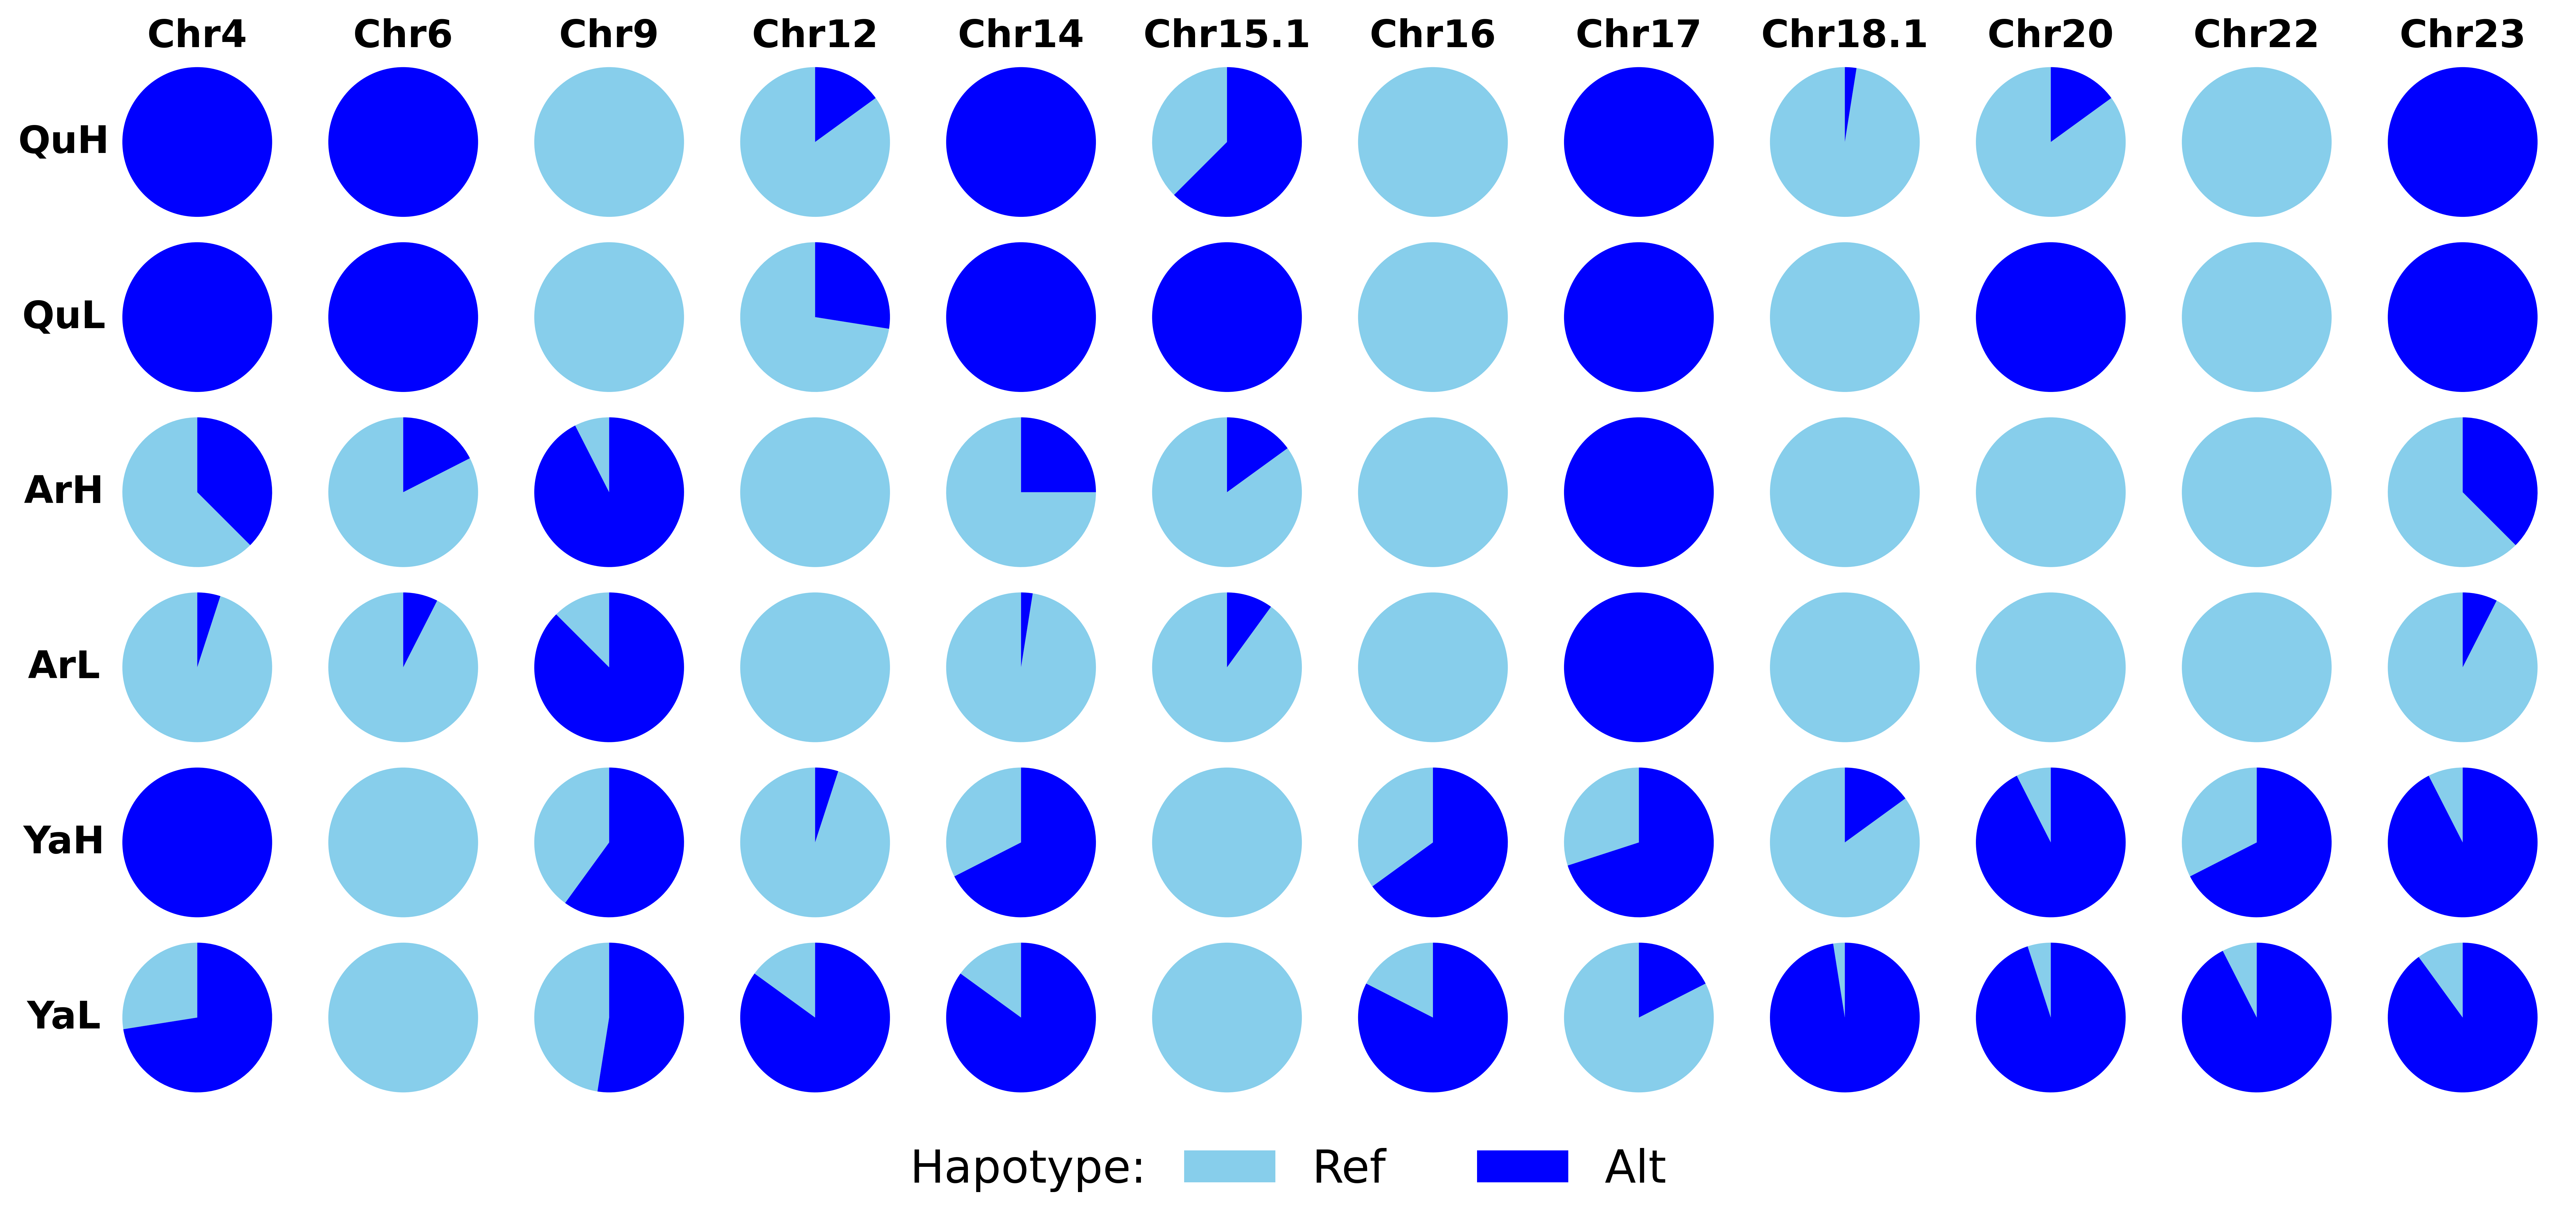

In [6]:
# -----------------------------
data_str = """INV\tAripo_H_ref\tAripo_H_alt\tAripo_L_ref\tAripo_L_alt\tQuare_H_ref\tQuare_H_alt\tQuare_L_ref\tQuare_L_alt\tYarra_H_ref\tYarra_H_alt\tYarra_L_ref\tYarra_L_alt
Chr1	20	20	20	20	2	38	0	40	35	5	40	0
Chr2	25	15	35	5	1	39	0	40	27	13	4	36
Chr3	38	2	40	0	6	34	0	40	35	5	5	35
Chr5	37	3	38	2	3	37	0	40	25	15	6	34
Chr7*	37	3	38	2	15	25	26	14	37	3	39	1
Chr10	35	5	37	3	2	38	0	40	37	3	28	12
Chr11*	21	19	25	15	39	1	40	0	9	31	40	0
Chr15.2	31	9	39	1	17	23	0	40	13	27	1	39
Chr18.2	37	3	40	0	3	37	0	40	34	6	0	40
Chr21*	28	12	37	3	29	11	40	0	0	40	2	38
"""

data_str = """INV\tAripo_H_ref\tAripo_H_alt\tAripo_L_ref\tAripo_L_alt\tQuare_H_ref\tQuare_H_alt\tQuare_L_ref\tQuare_L_alt\tYarra_H_ref\tYarra_H_alt\tYarra_L_ref\tYarra_L_alt
Chr4	25	15	38	2	0	40	0	40	0	40	11	29
Chr6	33	7	37	3	0	40	0	40	40	0	40	0
Chr9	3	37	5	35	40	0	40	0	16	24	19	21
Chr12	40	0	40	0	34	6	29	11	38	2	6	34
Chr14	30	10	39	1	0	40	0	40	13	27	6	34
Chr15.1	34	6	36	4	15	25	0	40	40	0	40	0
Chr16	40	0	40	0	40	0	40	0	14	26	7	33
Chr17	0	40	0	40	0	40	0	40	12	28	33	7
Chr18.1	40	0	40	0	39	1	40	0	34	6	1	39
Chr20	40	0	40	0	34	6	0	40	3	37	2	38
Chr22	40	0	40	0	40	0	40	0	13	27	3	37
Chr23	25	15	37	3	0	40	0	40	3	37	4	36
"""

df_counts = pd.read_csv(StringIO(data_str), sep="\t")

total = 40

# Mapping pop_order to real column prefixes
pop_map = {
    'QuH': 'Quare_H',
    'QuL': 'Quare_L',
    'ArH': 'Aripo_H',
    'ArL': 'Aripo_L',
    'YaH': 'Yarra_H',
    'YaL': 'Yarra_L'
}

pop_order = ['QuH', 'QuL', 'ArH', 'ArL', 'YaH', 'YaL']

colors = ['skyblue', 'blue']
labels = ['Ref', 'Alt']

samples = df_counts['INV'].tolist()

fig, axes = plt.subplots(
    len(pop_order), len(samples), 
    figsize=(14, 6), 
    dpi=600, 
    constrained_layout=True
)

for i, pop_abbr in enumerate(pop_order):
    prefix = pop_map[pop_abbr]
    for j, sample in enumerate(samples):
        ref_count = df_counts.loc[j, f"{prefix}_ref"]
        alt_count = df_counts.loc[j, f"{prefix}_alt"]
        freqs = [ref_count / total, alt_count / total]
        ax = axes[i, j] if len(pop_order) > 1 else axes[j]
        ax.pie(freqs, colors=colors, startangle=90, radius=0.7)
        ax.axis('equal')

        if i == 0:
            ax.set_title(sample, fontsize=15, fontweight="bold")
        if j == 0:
            ax.set_ylabel(pop_abbr, fontsize=15, fontweight="bold", rotation=0, labelpad=15, va='center')

from matplotlib.offsetbox import HPacker

# 1. Create the legend and assign it to a variable
leg = fig.legend(
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0),
    title='Hapotype:',
    fontsize=18,
    ncol=len(labels),
    title_fontsize=18,
    frameon=False,  
)

# 2. Extract the title and items, and repack them horizontally
leg._legend_box = HPacker(
    pad=0,
    sep=15,
    align="center",   # keep this
    children=leg._legend_box.get_children()
)

# Force the legend to use center alignment
leg.set_bbox_to_anchor((0.5, -0.1), transform=fig.transFigure)
leg._loc = 8  # 8 = 'lower center'

plt.savefig("./guppy_inv_hap.pdf", bbox_inches='tight', transparent=True)  # legend will now be included
plt.show()


# Supplmental Figures Genotype

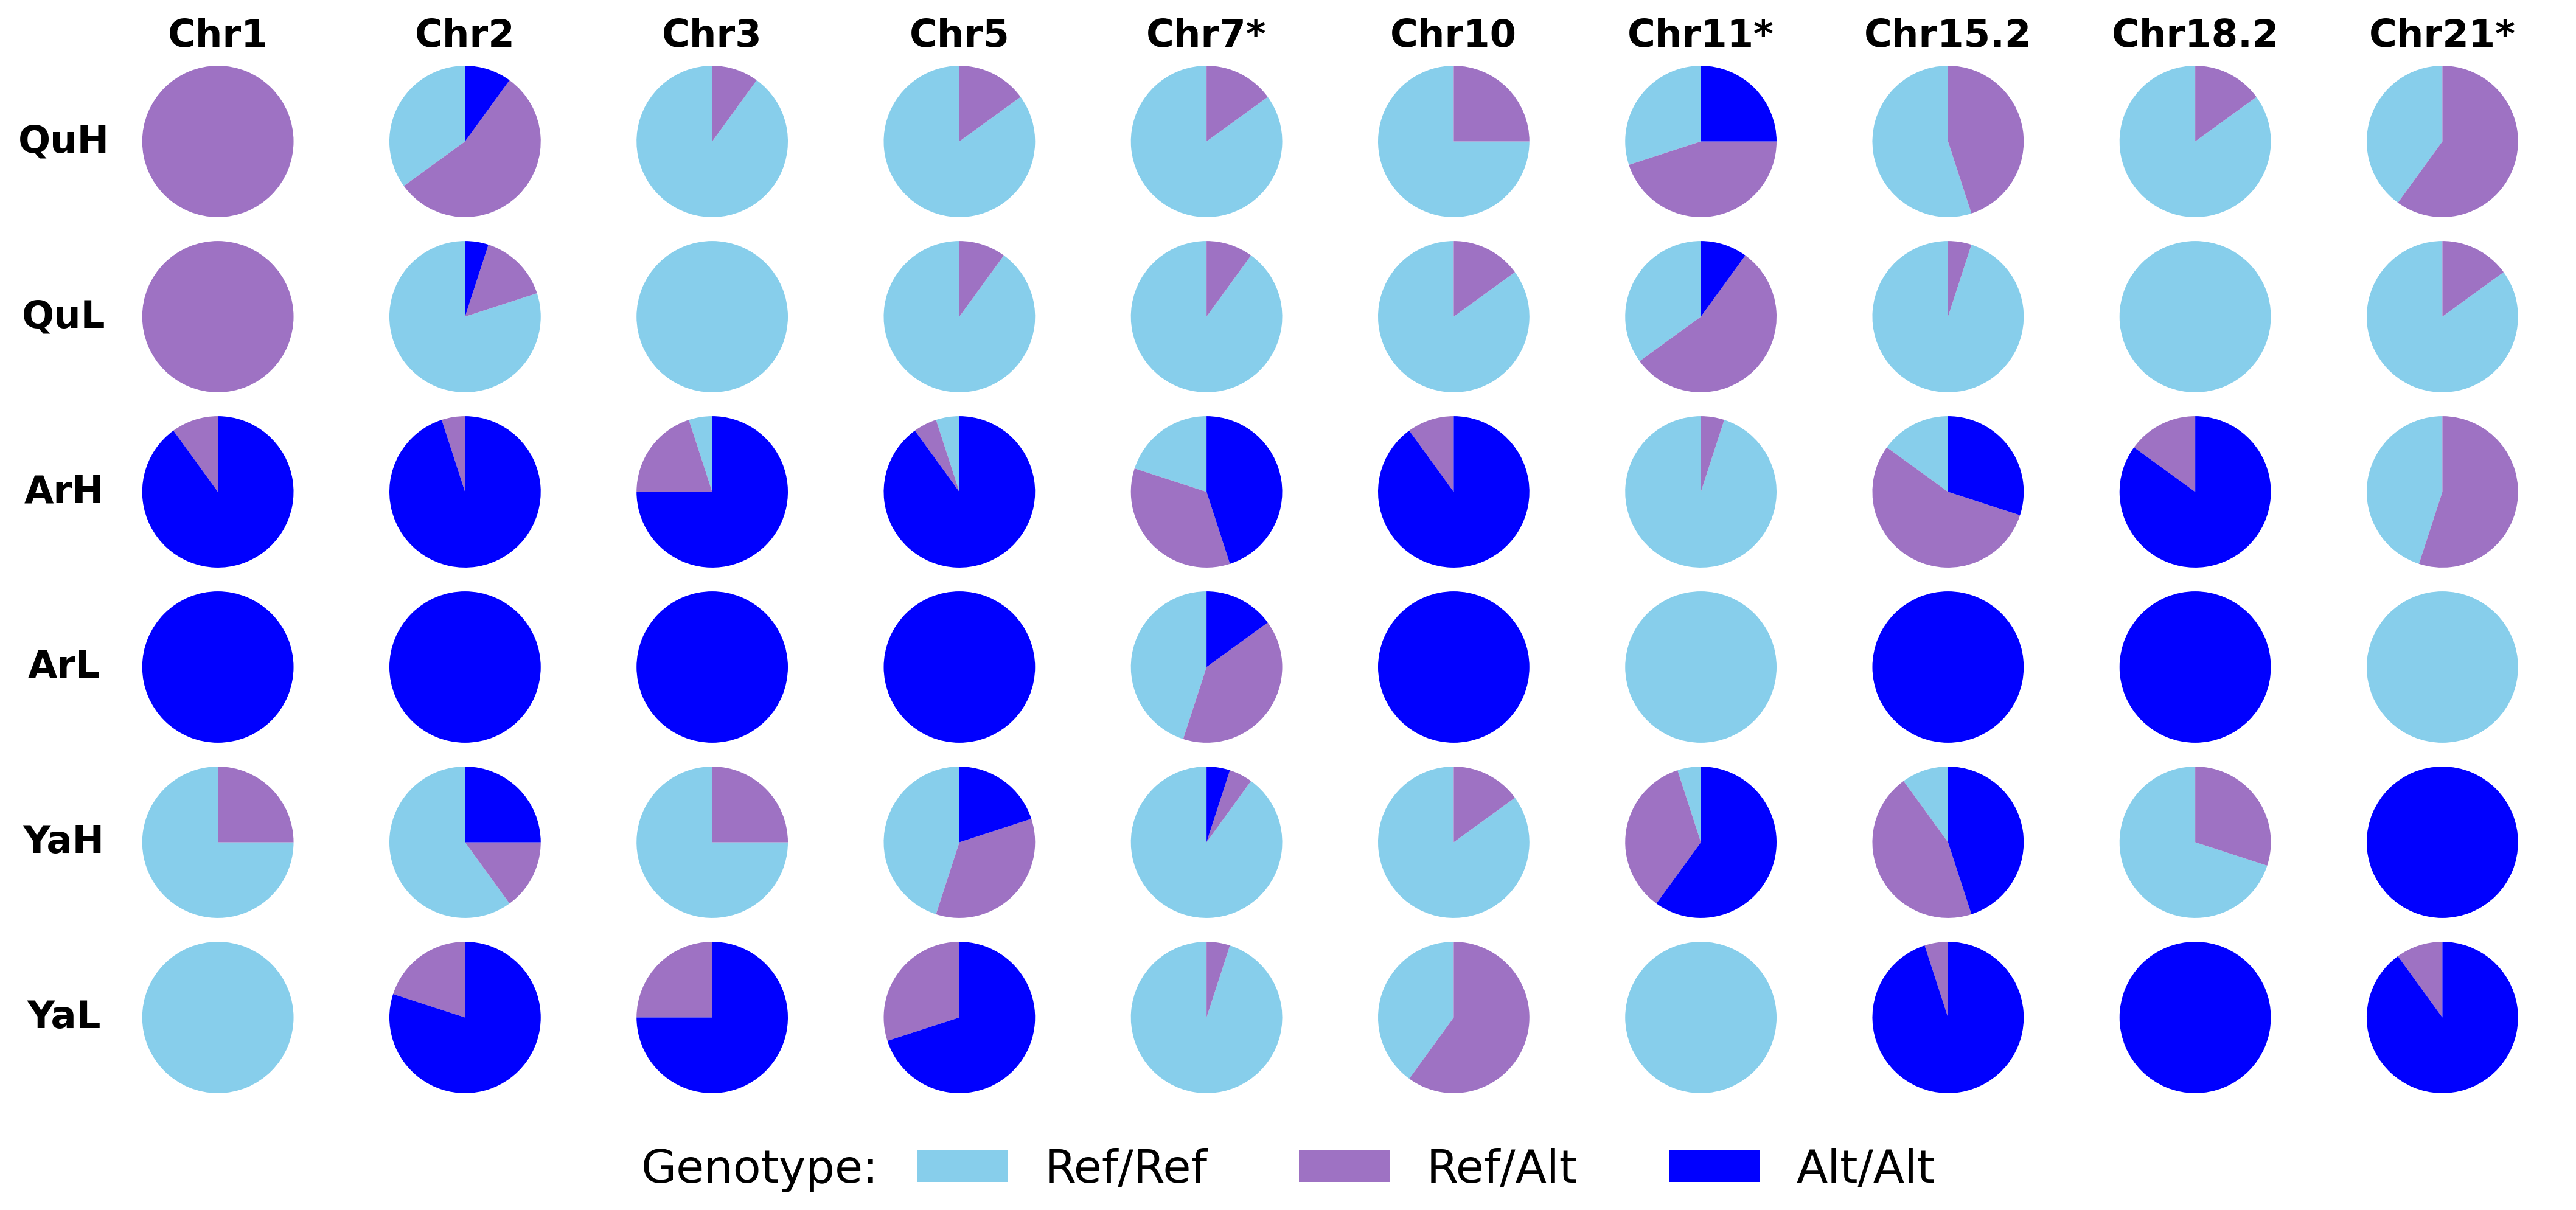

In [8]:

data_str = """INV\tQuH_R\tQuH_H\tQuH_A\tQuL_R\tQuL_H\tQuL_A\tArH_R\tArH_H\tArH_A\tArL_R\tArL_H\tArL_A\tYaH_R\tYaH_H\tYaH_A\tYaL_R\tYaL_H\tYaL_A
Chr1	0	1	0	0	1	0	0	0.1	0.9	0	0	1	0.75	0.25	0	1	0	0
Chr2	0.35	0.55	0.1	0.8	0.15	0.05	0	0.05	0.95	0	0	1	0.6	0.15	0.25	0	0.2	0.8
Chr3	0.9	0.1	0	1	0	0	0.05	0.2	0.75	0	0	1	0.75	0.25	0	0	0.25	0.75
Chr5	0.85	0.15	0	0.9	0.1	0	0.05	0.05	0.9	0	0	1	0.45	0.35	0.2	0	0.3	0.7
Chr7*	0.85	0.15	0	0.9	0.1	0	0.2	0.35	0.45	0.45	0.4	0.15	0.9	0.05	0.05	0.95	0.05	0
Chr10	0.75	0.25	0	0.85	0.15	0	0	0.1	0.9	0	0	1	0.85	0.15	0	0.4	0.6	0
Chr11*	0.3	0.45	0.25	0.35	0.55	0.1	0.95	0.05	0	1	0	0	0.05	0.35	0.6	1	0	0
Chr15.2	0.55	0.45	0	0.95	0.05	0	0.15	0.55	0.3	0	0	1	0.1	0.45	0.45	0	0.05	0.95
Chr18.2	0.85	0.15	0	1	0	0	0	0.15	0.85	0	0	1	0.7	0.3	0	0	0	1
Chr21*	0.4	0.6	0	0.85	0.15	0	0.45	0.55	0	1	0	0	0	0	1	0	0.1	0.9
"""

# data_str = """INV\tQuH_R\tQuH_H\tQuH_A\tQuL_R\tQuL_H\tQuL_A\tArH_R\tArH_H\tArH_A\tArL_R\tArL_H\tArL_A\tYaH_R\tYaH_H\tYaH_A\tYaL_R\tYaL_H\tYaL_A
# Chr4	0.45	0.35	0.2	0.9	0.1	0	0	0	1	0	0	1	0	0	1	0.1	0.35	0.55
# Chr6	0.65	0.35	0	0.9	0.05	0.05	0	0	1	0	0	1	1	0	0	1	0	0
# Chr9	0	0.15	0.85	0	0.25	0.75	1	0	0	1	0	0	0	0.8	0.2	0	0.95	0.05
# Chr12	1	0	0	1	0	0	0.7	0.3	0	0.45	0.55	0	0.9	0.1	0	0	0.3	0.7
# Chr14	0.55	0.4	0.05	0.95	0.05	0	0	0	1	0	0	1	0	0.65	0.35	0	0.3	0.7
# Chr15.1	0.75	0.2	0.05	0.8	0.2	0	0.05	0.65	0.3	0	0	1	1	0	0	1	0	0
# Chr16	1	0	0	1	0	0	1	0	0	1	0	0	0.15	0.4	0.45	0	0.35	0.65
# Chr17	0	0	1	0	0	1	0	0	1	0	0	1	0.15	0.3	0.55	0.65	0.35	0
# Chr18.1	1	0	0	1	0	0	0.95	0.05	0	1	0	0	0.7	0.3	0	0	0.05	0.95
# Chr20	1	0	0	1	0	0	0.7	0.3	0	0	0	1	0	0.15	0.85	0	0.1	0.9
# Chr22	1	0	0	1	0	0	1	0	0	1	0	0	0.15	0.35	0.5	0	0.15	0.85
# Chr23	0.35	0.55	0.1	0.75	0.35	0	0	0	1	0	0	1	0	0.15	0.85	0	0.2	0.8
# """

# Load data
df = pd.read_csv(StringIO(data_str), sep="\t")

# Setup
inv_names = df['INV'].tolist()
populations = ['QuH', 'QuL', 'ArH', 'ArL', 'YaH', 'YaL']
colors = ['skyblue', '#9E72C3', 'blue']
labels = ['Ref/Ref', 'Ref/Alt', 'Alt/Alt']

# --- Main figure ---
fig, axes = plt.subplots(len(populations), len(inv_names), figsize=(14, 6), dpi=300,
                         constrained_layout=True)

# Plot pie charts
for i, pop in enumerate(populations):
    for j, inv in enumerate(inv_names):
        freqs = df.loc[df['INV'] == inv, [f"{pop}_R", f"{pop}_H", f"{pop}_A"]].values.flatten()
        ax = axes[i, j]
        ax.pie(freqs, colors=colors, startangle=90, radius=0.7)
        ax.axis('equal')

        if i == 0:
            ax.set_title(inv, fontsize=15, fontweight="bold")
        if j == 0:
            ax.set_ylabel(pop, fontsize=15, rotation=0, labelpad=15, va='center', fontweight="bold")

from matplotlib.offsetbox import HPacker

# 1. Create the legend and assign it to a variable
leg = fig.legend(
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0),
    title='Genotype:',
    fontsize=18,
    ncol=len(labels),
    title_fontsize=18,
    frameon=False,   # 🔑 removes the legend box/frame
)

# 2. Extract the title and items, and repack them horizontally
# Repack horizontally
leg._legend_box = HPacker(
    pad=0,
    sep=15,
    align="center",   # keep this
    children=leg._legend_box.get_children()
)

# 🔑 Critical: force the legend to use center alignment
leg.set_bbox_to_anchor((0.5, -0.1), transform=fig.transFigure)
leg._loc = 8  # 8 = 'lower center'

# Save figure with legend included
plt.savefig("guppy_inv_pies.pdf", bbox_inches='tight', dpi=300, transparent=True)
plt.show()
